In [105]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
from chart_studio.plotly import plot,iplot
%matplotlib inline

In [106]:
pwd

'C:\\Users\\ROHAN\\Desktop\\Project\\Flight Price'

In [107]:
os.chdir(r'C:\Users\ROHAN\Desktop\Project\Flight Price')

In [108]:
pwd

'C:\\Users\\ROHAN\\Desktop\\Project\\Flight Price'

In [109]:
df=pd.read_excel('Data_Train.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [110]:
import ydata_profiling as ypf
ypf.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/11 [00:00<?, ?it/s]
%|███████▌                                                                           | 1/11 [00:00<00:04,  2.36it/s]
%|█████████████████████████████████████▋                                             | 5/11 [00:00<00:01,  5.85it/s]
%|█████████████████████████████████████████████▎                                     | 6/11 [00:01<00:00,  5.47it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  8.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [111]:
len(df)

10683

In [112]:
df.shape

(10683, 11)

In [113]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [114]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [115]:
df.dropna(how='any',inplace=True)

In [116]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [117]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [118]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [119]:
df['Day_of_Journey']=df['Date_of_Journey'].dt.day
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1


In [120]:
df['Month_of_Journey']=df['Date_of_Journey'].dt.month
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [121]:
df.drop(['Date_of_Journey'], inplace=True, axis=1)
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [122]:
df['Dep_Time']=pd.to_datetime(df['Dep_Time'], format='%H:%M')
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,Banglore,New Delhi,BLR → DEL,1900-01-01 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,1900-01-01 05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1900-01-01 09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1900-01-01 18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1900-01-01 16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3


In [123]:
df['Dep_Hour']=df['Dep_Time'].dt.hour
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour
0,IndiGo,Banglore,New Delhi,BLR → DEL,1900-01-01 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,1900-01-01 05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1900-01-01 09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1900-01-01 18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,18
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1900-01-01 16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,16


In [124]:
df['Dep_Min']=df['Dep_Time'].dt.minute
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,1900-01-01 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,1900-01-01 05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1900-01-01 09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1900-01-01 18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1900-01-01 16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [125]:
df.drop(['Dep_Time'], inplace=True, axis=1)
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [126]:
df['Arrival_Time']=pd.to_datetime(df['Arrival_Time'], format='mixed')
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-01-12 13:15:00,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-01-12 23:30:00,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-01-12 21:35:00,4h 45m,1 stop,No info,13302,1,3,16,50


In [127]:
df['Arrival_Hour']=df['Arrival_Time'].dt.hour
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,22,20,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-01-12 13:15:00,7h 25m,2 stops,No info,7662,1,5,5,50,13
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,9,25,4
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-01-12 23:30:00,5h 25m,1 stop,No info,6218,12,5,18,5,23
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-01-12 21:35:00,4h 45m,1 stop,No info,13302,1,3,16,50,21


In [128]:
df['Arrival_Min']=df['Arrival_Time'].dt.minute
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-01-12 13:15:00,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-01-12 23:30:00,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-01-12 21:35:00,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [129]:
df.drop(['Arrival_Time'], inplace=True, axis=1)
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [130]:
Duration=df['Duration'].str.split(' ',expand=True) 
Duration


,0,1
0,2h,50m
1,7h,25m
2,19h,None
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,None
10681,2h,40m


In [131]:
Duration[1]=Duration[1].fillna('00m')
Duration

,0,1
0,2h,50m
1,7h,25m
2,19h,00m
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,00m
10681,2h,40m


In [132]:
df['Duration_Hr']=Duration[0].apply(lambda x: x[:-1]) 
df['Duration_Hr']


0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: Duration_Hr, Length: 10682, dtype: object

In [133]:
df['Duration_Min']=Duration[1].apply(lambda x: x[:-1]) 
df['Duration_Min']


0        50
1        25
2        00
3        25
4        45
         ..
10678    30
10679    35
10680    00
10681    40
10682    20
Name: Duration_Min, Length: 10682, dtype: object

In [134]:
df.drop('Duration', inplace=True, axis=1)
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [135]:
cf.set_config_file(theme='ggplot',sharing='public',offline=True)

In [136]:
print (df['Airline'].value_counts())


Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


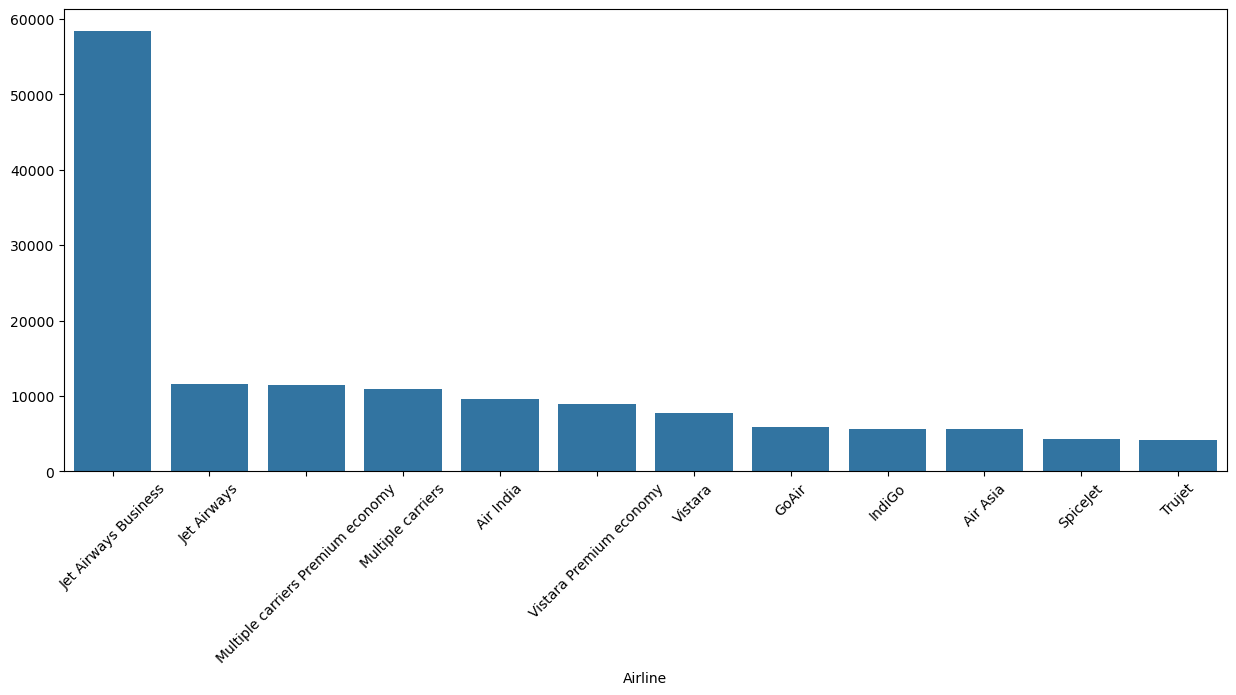

In [137]:

Airprices=df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,6))
sns.barplot(x= Airprices.index,y=Airprices.values)
plt.xticks(rotation=45)
plt.show()


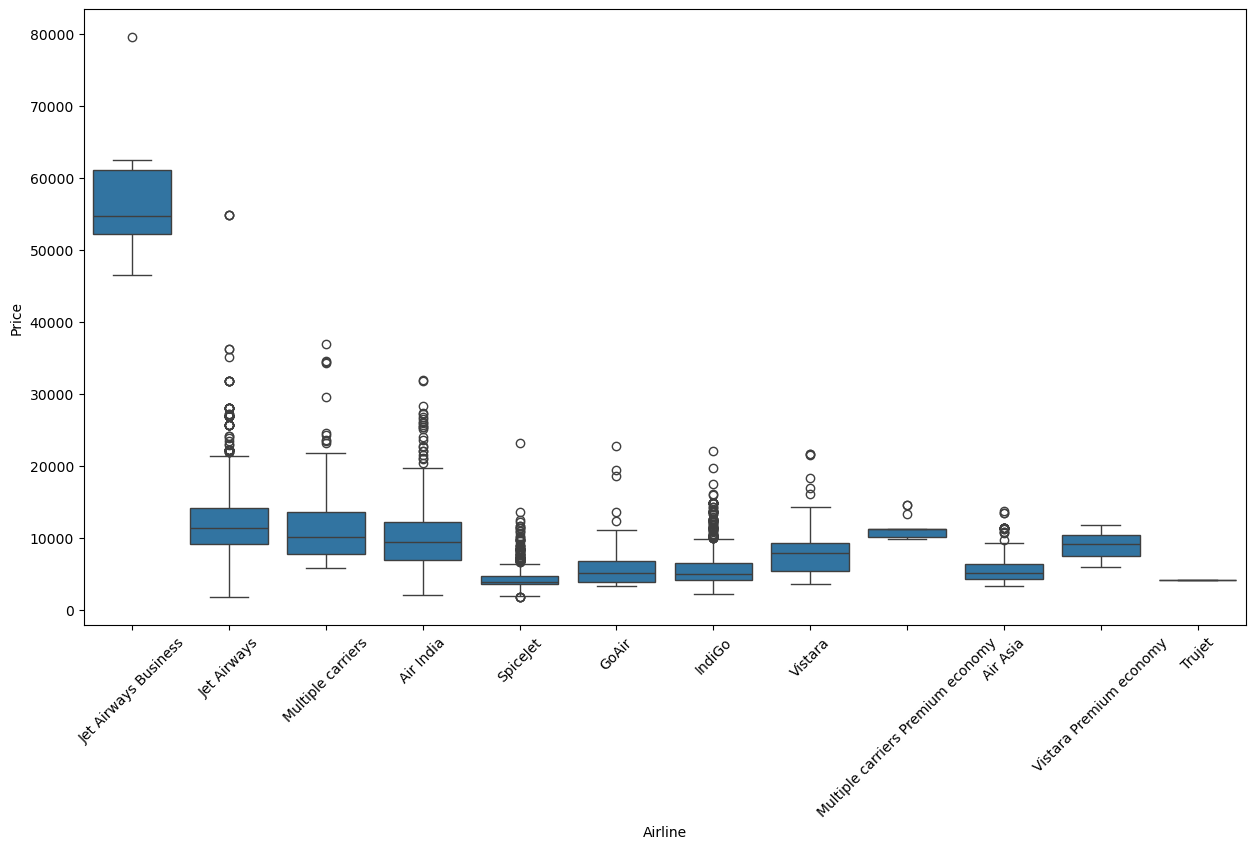

In [138]:

plt.figure(figsize=(15,8))
sns.boxplot(y='Price',x='Airline',data= df.sort_values('Price',ascending=False))
plt.xticks(rotation=45)
plt.show()


In [139]:
print (df.groupby(['Airline','Total_Stops'])['Price'].mean())


Airline                            Total_Stops
Air Asia                           1 stop          7078.325581
                                   2 stops         6341.888889
                                   non-stop        4492.331492
Air India                          1 stop          9041.509259
                                   2 stops        12092.779101
                                   3 stops        12208.054054
                                   4 stops        17686.000000
                                   non-stop        5605.326139
GoAir                              1 stop          6884.676471
                                   non-stop        4726.173913
IndiGo                             1 stop          7104.717528
                                   2 stops         7507.526316
                                   non-stop        4731.174053
Jet Airways                        1 stop         12512.741223
                                   2 stops        13387.247467
        

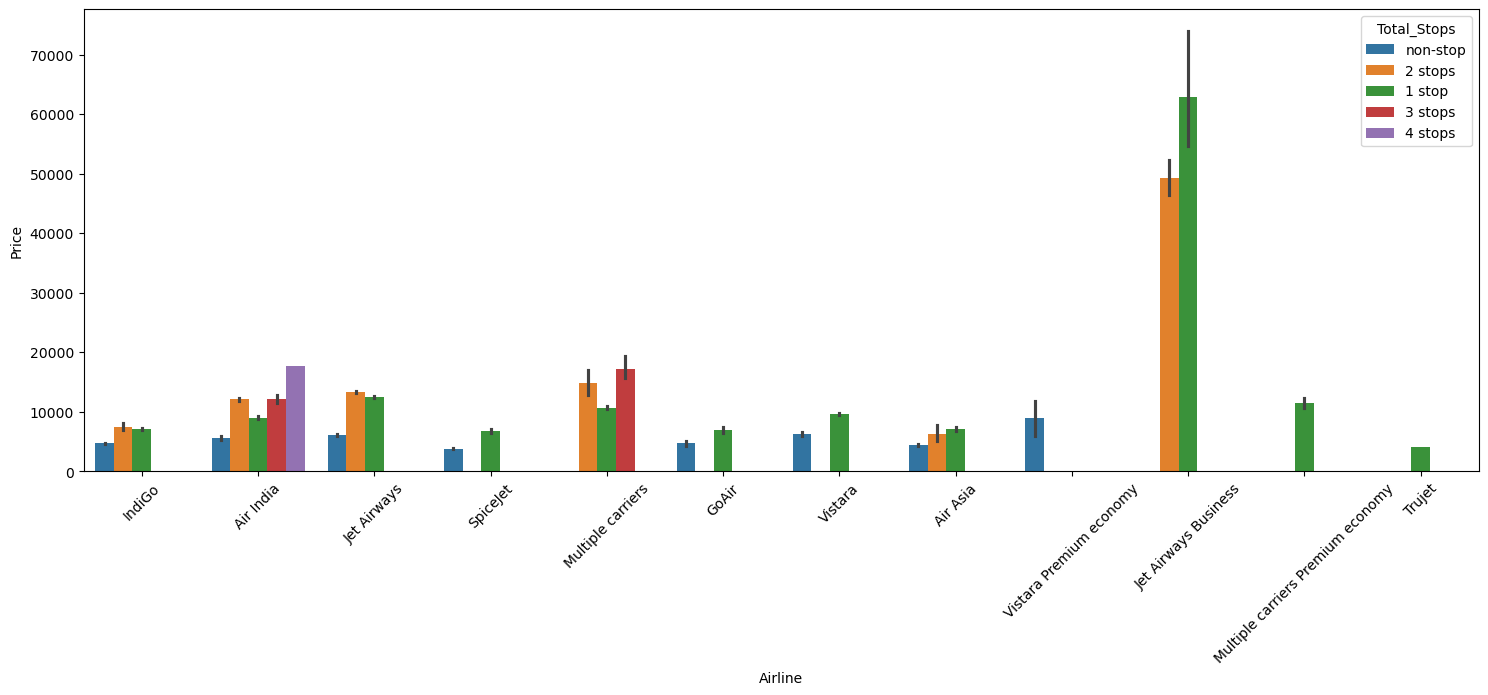

In [140]:
plt.figure(figsize=(18,6))
ax=sns.barplot(x=df['Airline'],y=df['Price'],hue=df['Total_Stops'])
plt.xticks(rotation=45)
plt.show()


In [141]:
print (df['Source'].value_counts())


Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64


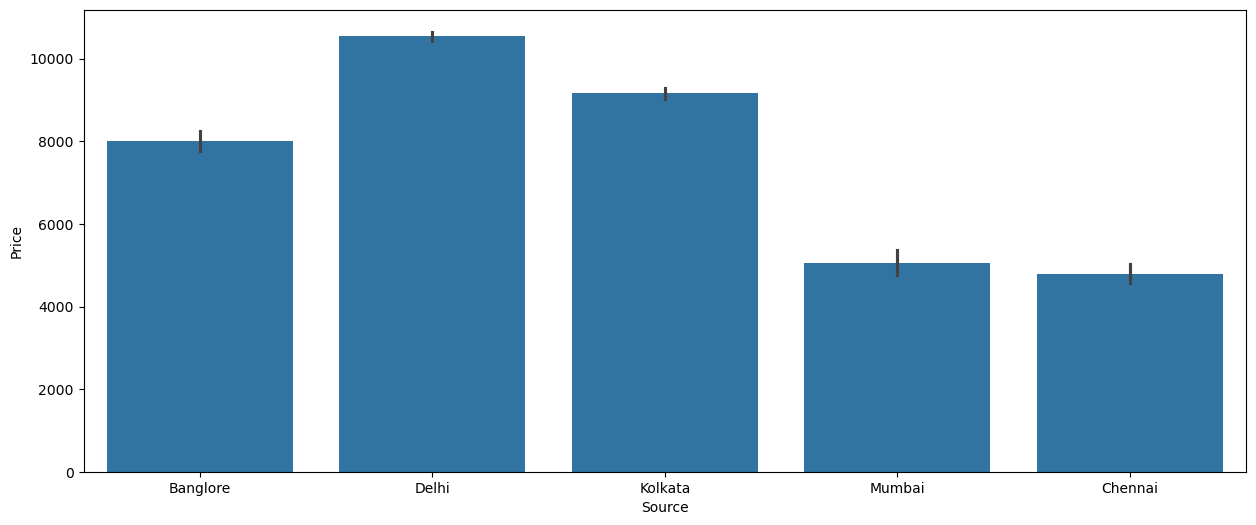

In [142]:
plt.figure(figsize=(15,6))
sns.barplot(y='Price',x='Source',data=df.sort_values('Price',ascending=False))
plt.show()


In [143]:
print (df['Destination'].value_counts())


Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64


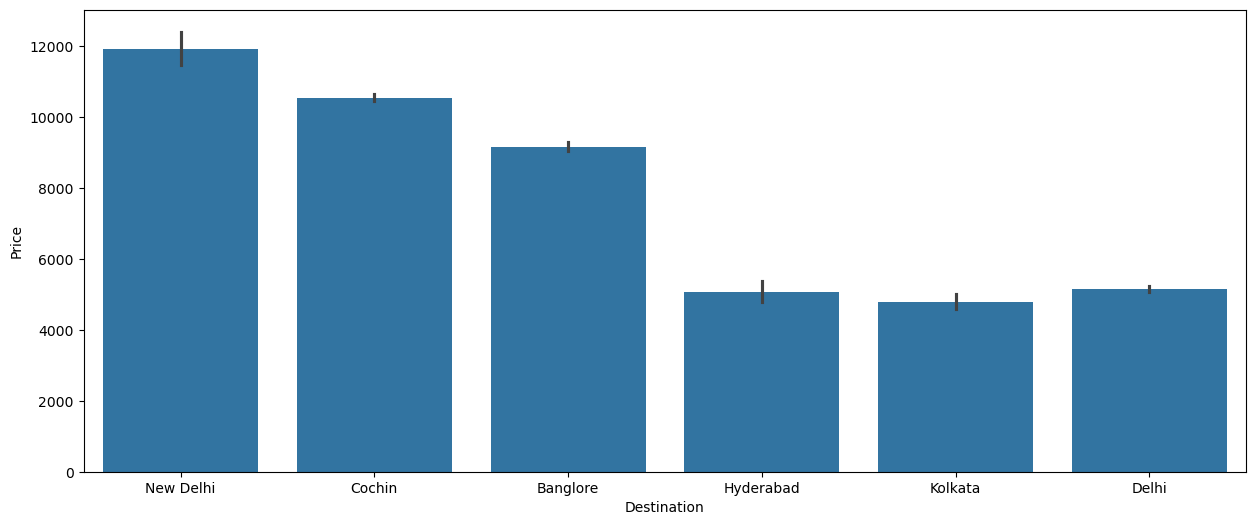

In [144]:
plt.figure(figsize=(15,6))
sns.barplot(y='Price',x='Destination',data=df.sort_values('Price',ascending=False))
plt.show()


In [145]:
for i in df:
    df.replace('New Delhi','Delhi',inplace=True)

In [146]:
df['Destination'].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        2197
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

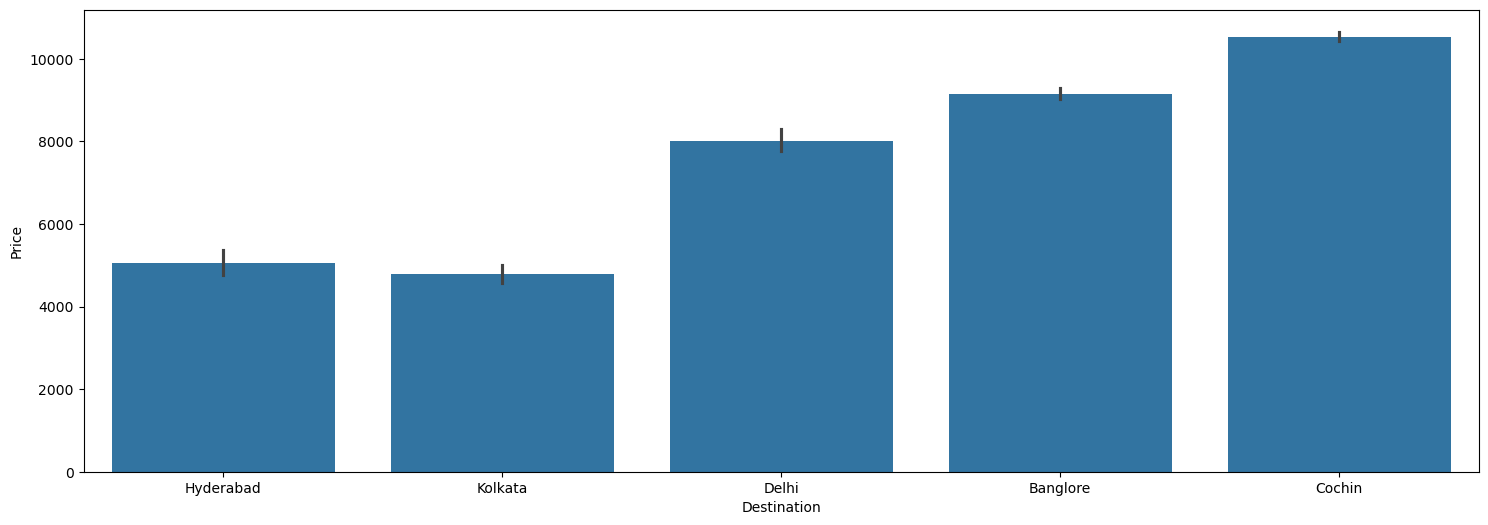

In [147]:
plt.figure(figsize=(18,6))
sns.barplot(y='Price',x='Destination', data=df.sort_values('Price'))
plt.show()

In [148]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,IndiGo,Banglore,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [149]:
df_corr=df.iloc[:,7:]
df_corr

,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,24,3,22,20,1,10,2,50
1,1,5,5,50,13,15,7,25
2,9,6,9,25,4,25,19,00
3,12,5,18,5,23,30,5,25
4,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...
10678,9,4,19,55,22,25,2,30
10679,27,4,20,45,23,20,2,35
10680,27,4,8,20,11,20,3,00
10681,1,3,11,30,14,10,2,40


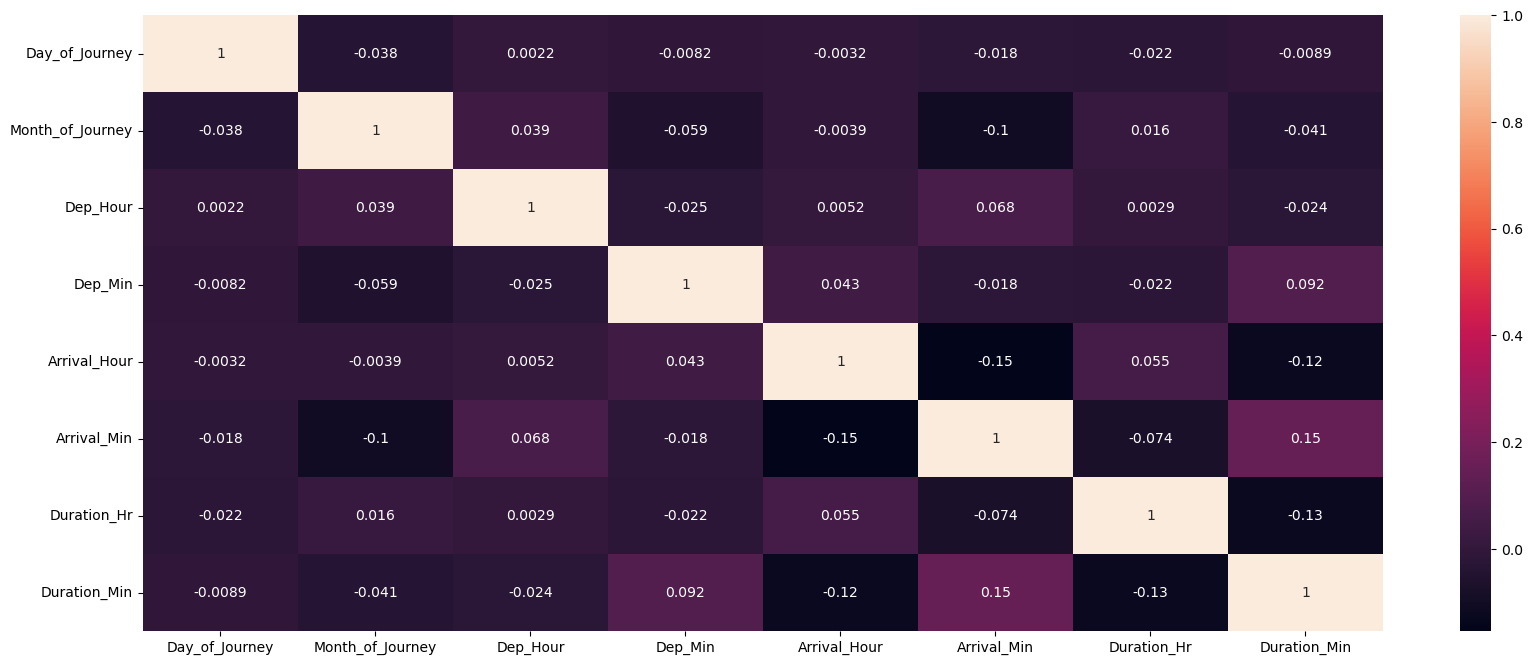

In [150]:
plt.figure(figsize=(20,8))
sns.heatmap(df_corr.corr(),annot=True)
plt.show()


In [151]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,IndiGo,Banglore,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [152]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df.iloc[:,0]=le.fit_transform(df.iloc[:,0])
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,Banglore,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,1,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,4,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,3,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,3,Banglore,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,1,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,4,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,10,Banglore,Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [153]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df.iloc[:,1]=le.fit_transform(df.iloc[:,1])
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,1,3,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,4,2,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,3,3,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,3,0,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,1,3,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,4,0,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,10,0,Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [154]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df.iloc[:,2]=le.fit_transform(df.iloc[:,2])
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,2,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,1,3,0,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,4,2,1,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,3,3,0,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,3,0,2,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,1,3,0,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,4,0,2,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,10,0,2,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [155]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df.iloc[:,4]=le.fit_transform(df.iloc[:,4])
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,2,BLR → DEL,4,No info,3897,24,3,22,20,1,10,2,50
1,1,3,0,CCU → IXR → BBI → BLR,1,No info,7662,1,5,5,50,13,15,7,25
2,4,2,1,DEL → LKO → BOM → COK,1,No info,13882,9,6,9,25,4,25,19,00
3,3,3,0,CCU → NAG → BLR,0,No info,6218,12,5,18,5,23,30,5,25
4,3,0,2,BLR → NAG → DEL,0,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,CCU → BLR,4,No info,4107,9,4,19,55,22,25,2,30
10679,1,3,0,CCU → BLR,4,No info,4145,27,4,20,45,23,20,2,35
10680,4,0,2,BLR → DEL,4,No info,7229,27,4,8,20,11,20,3,00
10681,10,0,2,BLR → DEL,4,No info,12648,1,3,11,30,14,10,2,40


In [156]:
df.drop(['Route'], inplace=True, axis=1)
df

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,2,4,No info,3897,24,3,22,20,1,10,2,50
1,1,3,0,1,No info,7662,1,5,5,50,13,15,7,25
2,4,2,1,1,No info,13882,9,6,9,25,4,25,19,00
3,3,3,0,0,No info,6218,12,5,18,5,23,30,5,25
4,3,0,2,0,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,4,No info,4107,9,4,19,55,22,25,2,30
10679,1,3,0,4,No info,4145,27,4,20,45,23,20,2,35
10680,4,0,2,4,No info,7229,27,4,8,20,11,20,3,00
10681,10,0,2,4,No info,12648,1,3,11,30,14,10,2,40


In [157]:
df.drop(['Additional_Info'], inplace=True, axis=1)
df

,Airline,Source,Destination,Total_Stops,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,2,4,3897,24,3,22,20,1,10,2,50
1,1,3,0,1,7662,1,5,5,50,13,15,7,25
2,4,2,1,1,13882,9,6,9,25,4,25,19,00
3,3,3,0,0,6218,12,5,18,5,23,30,5,25
4,3,0,2,0,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,4,4107,9,4,19,55,22,25,2,30
10679,1,3,0,4,4145,27,4,20,45,23,20,2,35
10680,4,0,2,4,7229,27,4,8,20,11,20,3,00
10681,10,0,2,4,12648,1,3,11,30,14,10,2,40


In [158]:
df=df.astype(int)

In [159]:
df.dtypes

Airline             int64
Source              int64
Destination         int64
Total_Stops         int64
Price               int64
Day_of_Journey      int64
Month_of_Journey    int64
Dep_Hour            int64
Dep_Min             int64
Arrival_Hour        int64
Arrival_Min         int64
Duration_Hr         int64
Duration_Min        int64
dtype: object

In [160]:
x1=df.iloc[:,0:4]
x1

,Airline,Source,Destination,Total_Stops
0,3,0,2,4
1,1,3,0,1
2,4,2,1,1
3,3,3,0,0
4,3,0,2,0
...,...,...,...,...
10678,0,3,0,4
10679,1,3,0,4
10680,4,0,2,4
10681,10,0,2,4


In [161]:
x2=df.iloc[:,5:]
x2

,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,24,3,22,20,1,10,2,50
1,1,5,5,50,13,15,7,25
2,9,6,9,25,4,25,19,0
3,12,5,18,5,23,30,5,25
4,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...
10678,9,4,19,55,22,25,2,30
10679,27,4,20,45,23,20,2,35
10680,27,4,8,20,11,20,3,0
10681,1,3,11,30,14,10,2,40


In [162]:
x=pd.concat([x1,x2], axis=1).values
x

array([[ 3,  0,  2, ..., 10,  2, 50],
       [ 1,  3,  0, ..., 15,  7, 25],
       [ 4,  2,  1, ..., 25, 19,  0],
       ...,
       [ 4,  0,  2, ..., 20,  3,  0],
       [10,  0,  2, ..., 10,  2, 40],
       [ 1,  2,  1, ..., 15,  8, 20]])

In [163]:
y=df['Price'].values
y

array([ 3897,  7662, 13882, ...,  7229, 12648, 11753])

In [164]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit_transform(x)

array([[-0.41080484, -1.65835945,  0.81505355, ..., -0.8900139 ,
        -0.97071784,  1.27901455],
       [-1.26115217,  0.89001433, -1.15941114, ..., -0.5870944 ,
        -0.38207336, -0.19628277],
       [ 0.01436882,  0.04055641, -0.17217879, ...,  0.0187446 ,
         1.0306734 , -1.67158009],
       ...,
       [ 0.01436882, -1.65835945,  0.81505355, ..., -0.2841749 ,
        -0.85298895, -1.67158009],
       [ 2.56541078, -1.65835945,  0.81505355, ..., -0.8900139 ,
        -0.97071784,  0.68889562],
       [-1.26115217,  0.04055641, -0.17217879, ..., -0.5870944 ,
        -0.26434447, -0.49134224]])

In [165]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(x)

array([[0.27272727, 0.        , 0.5       , ..., 0.18181818, 0.02173913,
        0.90909091],
       [0.09090909, 0.75      , 0.        , ..., 0.27272727, 0.13043478,
        0.45454545],
       [0.36363636, 0.5       , 0.25      , ..., 0.45454545, 0.39130435,
        0.        ],
       ...,
       [0.36363636, 0.        , 0.5       , ..., 0.36363636, 0.04347826,
        0.        ],
       [0.90909091, 0.        , 0.5       , ..., 0.18181818, 0.02173913,
        0.72727273],
       [0.09090909, 0.5       , 0.25      , ..., 0.27272727, 0.15217391,
        0.36363636]])

In [166]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.30, random_state=7)
print(x.shape)
print(y.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(10682, 12)
(10682,)
(7477, 12)
(3205, 12)
(7477,)
(3205,)


In [167]:
from sklearn.ensemble import AdaBoostRegressor
abr=AdaBoostRegressor()
abr.fit(x_train, y_train)

AdaBoostRegressor()

In [168]:
abr_y_pred=abr.predict(x_test)
abr_y_pred

array([12747.29906877,  7064.11034955, 11356.93777293, ...,
        7064.11034955,  9176.78202247, 12162.02637795])

In [169]:
from sklearn.metrics import r2_score
abr_acc=r2_score(y_test, abr_y_pred)
abr_acc

0.4393280887987724

In [170]:
abr_final_y_pred=abr.predict(x)
abr_final_y_pred

array([ 8263.05660377, 13636.09649123, 13138.8727687 , ...,
        7912.7088175 , 14518.75647668, 11792.32971014])

In [172]:
from sklearn.metrics import r2_score
abr_final_acc=r2_score(y, abr_final_y_pred)
abr_final_acc

0.47227799754468414

In [173]:
from sklearn.ensemble import ExtraTreesRegressor
etr=ExtraTreesRegressor()
etr.fit(x_train, y_train)

ExtraTreesRegressor()

In [174]:
etr_y_pred=etr.predict(x_test)
etr_y_pred

array([14441.  ,  3922.42, 11063.71, ...,  5695.35,  5703.31, 12329.15])

In [175]:
from sklearn.metrics import r2_score
etr_acc=r2_score(y_test, etr_y_pred)
etr_acc

0.7874021707770757

In [176]:
etr_final_y_pred=etr.predict(x)
etr_final_y_pred

array([ 5164.52166667,  7662.        , 13882.        , ...,
        6213.5       , 12648.        , 11753.        ])

In [177]:
from sklearn.metrics import r2_score
etr_final_acc=r2_score(y, etr_final_y_pred)
etr_final_acc

0.9215989486121634

In [178]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
rfr.fit(x_train, y_train)

RandomForestRegressor()

In [179]:
rfr_y_pred=rfr.predict(x_test)
rfr_y_pred

array([14327.39333333,  3930.12      , 10915.64      , ...,
        6319.4925    ,  5307.25      , 12441.63816667])

In [180]:
from sklearn.metrics import r2_score
rfr_acc=r2_score(y_test, rfr_y_pred)
rfr_acc

0.8107300684023843

In [181]:
rfr_final_y_pred=rfr.predict(x)
rfr_final_y_pred

array([ 4937.76988095,  7346.69      , 13653.79      , ...,
        6027.87988095, 14215.57      , 11871.68      ])

In [182]:
from sklearn.metrics import r2_score
rfr_final_acc=r2_score(y, rfr_final_y_pred)
rfr_final_acc

0.9140964679918342

In [188]:
from catboost import CatBoostRegressor
cbr=CatBoostRegressor()
cbr.fit(x_train, y_train)

Learning rate set to 0.056264
0:	learn: 4512.9780336	total: 145ms	remaining: 2m 25s
1:	learn: 4377.3924513	total: 149ms	remaining: 1m 14s
2:	learn: 4240.8977918	total: 152ms	remaining: 50.6s
3:	learn: 4121.4205584	total: 159ms	remaining: 39.5s
4:	learn: 4004.2855136	total: 163ms	remaining: 32.5s
5:	learn: 3894.4928670	total: 166ms	remaining: 27.6s
6:	learn: 3795.1186038	total: 170ms	remaining: 24.1s
7:	learn: 3711.0582539	total: 174ms	remaining: 21.6s
8:	learn: 3636.6164786	total: 177ms	remaining: 19.5s
9:	learn: 3555.2086831	total: 180ms	remaining: 17.8s
10:	learn: 3477.6719164	total: 184ms	remaining: 16.5s
11:	learn: 3407.6147959	total: 189ms	remaining: 15.6s
12:	learn: 3341.4280905	total: 194ms	remaining: 14.7s
13:	learn: 3281.9287565	total: 196ms	remaining: 13.8s
14:	learn: 3218.5590529	total: 198ms	remaining: 13s
15:	learn: 3159.6021789	total: 201ms	remaining: 12.4s
16:	learn: 3107.1552464	total: 204ms	remaining: 11.8s
17:	learn: 3062.2480102	total: 207ms	remaining: 11.3s
18:	lear

In [189]:
cbr_y_pred=cbr.predict(x_test)
cbr_y_pred

array([13947.47255287,  4400.08157515, 11156.50606436, ...,
        6172.2617781 ,  4272.37958649, 12469.71235823])

In [190]:
from sklearn.metrics import r2_score
cbr_acc=r2_score(y_test, cbr_y_pred)
cbr_acc

0.8414905498517996

In [191]:
final_cbr_y_pred=cbr.predict(x)
final_cbr_y_pred

array([ 5150.90630857,  8618.82771332, 13871.37837389, ...,
        6066.57030156, 14908.49485647, 11708.49325615])

In [192]:
from sklearn.metrics import r2_score
final_cbr_acc=r2_score(y, final_cbr_y_pred)
final_cbr_acc

0.8917936780993412

In [196]:
from lightgbm import LGBMRegressor
lgbm=LGBMRegressor()
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 7477, number of used features: 12
[LightGBM] [Info] Start training from score 9089.906513


LGBMRegressor()

In [197]:
lgbm_y_pred=lgbm.predict(x_test)
lgbm_y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



array([14357.41762689,  4681.74261045, 11146.01474804, ...,
        5731.02074224,  5078.80593594, 12450.8906952 ])

In [199]:
from sklearn.metrics import r2_score
lgbm_acc=r2_score(y_test, lgbm_y_pred)
lgbm_acc

0.8403486463000034

In [200]:
final_lgbm_y_pred=lgbm.predict(x)
final_lgbm_y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



array([ 4941.37240466,  9839.7643258 , 13362.36348963, ...,
        5906.85125657, 16507.44863495, 11943.43811635])

In [201]:
from sklearn.metrics import r2_score
final_lgbm_acc=r2_score(y, final_lgbm_y_pred)
final_lgbm_acc

0.863318416669348

In [202]:
from xgboost import XGBRFRegressor
xgb=XGBRFRegressor()
xgb.fit(x_train, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [203]:
xgb_y_pred=xgb.predict(x_test)
xgb_y_pred

array([13582.052 ,  4598.5244, 11968.54  , ...,  5468.4004,  6215.3345,
       11881.749 ], dtype=float32)

In [204]:
from sklearn.metrics import r2_score
xgb_acc=r2_score(y_test, xgb_y_pred)
xgb_acc

0.7496487498283386

In [205]:
final_xgb_y_pred=xgb.predict(x)
final_xgb_y_pred

array([ 5476.3374, 10426.101 , 13078.837 , ...,  6229.498 , 15959.974 ,
       10697.583 ], dtype=float32)

In [207]:
from sklearn.metrics import r2_score
final_xgb_acc=r2_score(y, final_xgb_y_pred)
final_xgb_acc

0.763408362865448

In [209]:
import pickle

In [211]:
pickle.dump(cbr, open('cat_model.pkl', 'wb'))
model=pickle.load(open('cat_model.pkl', 'rb'))

In [213]:
model.predict(x)

array([ 5150.90630857,  8618.82771332, 13871.37837389, ...,
        6066.57030156, 14908.49485647, 11708.49325615])

In [214]:
pip install flask_cors

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [215]:
df

,Airline,Source,Destination,Total_Stops,Price,Day_of_Journey,Month_of_Journey,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hr,Duration_Min
0,3,0,2,4,3897,24,3,22,20,1,10,2,50
1,1,3,0,1,7662,1,5,5,50,13,15,7,25
2,4,2,1,1,13882,9,6,9,25,4,25,19,0
3,3,3,0,0,6218,12,5,18,5,23,30,5,25
4,3,0,2,0,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,4,4107,9,4,19,55,22,25,2,30
10679,1,3,0,4,4145,27,4,20,45,23,20,2,35
10680,4,0,2,4,7229,27,4,8,20,11,20,3,0
10681,10,0,2,4,12648,1,3,11,30,14,10,2,40


In [217]:
df.to_csv('deploy_df.csv')